<a href="https://colab.research.google.com/github/Raulfb04/Simulaci-n-1/blob/main/Prueba_de_frecuencias.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prueba de Frecuencias (Chi-cuadrada)

En esta práctica vamos a aplicar la **Prueba de Frecuencias** para verificar si un conjunto de números aleatorios sigue una distribución **Uniforme U(0,1)**.

Planteamos las hipótesis:

- **H₀:** Los datos siguen una distribución uniforme (son aleatorios).
- **H₁:** Los datos NO siguen una distribución uniforme (no son aleatorios).

Para evaluar esto, dividimos el intervalo $[0,1]$ en k subintervalos y comparamos:

- Frecuencias **observadas** $O_i$
- Frecuencias **esperadas** $E_i$ (si fuera uniforme, deberían ser parecidas)

El estadístico de prueba es:

$
X^2 = \sum_{i=1}^{k} \frac{(O_i - E_i)^2}{E_i}
$

Después comparamos $X^2$ con el valor crítico de chi-cuadrada para decidir si se rechaza o no $H_0$.

In [1]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt
from tabulate import tabulate

In [2]:
data = [
    0.78961, 0.05230, 0.10699, 0.55877, 0.14151,
    0.76086, 0.12079, 0.27738, 0.65726, 0.79269,
    0.80548, 0.82654, 0.29453, 0.20852, 0.42989,
    0.58518, 0.98611, 0.34488, 0.34358, 0.11537,
    0.89898, 0.57880, 0.67621, 0.05010, 0.00121,
    0.28269, 0.73059, 0.70119, 0.18284, 0.49962,
    0.38618, 0.76910, 0.68334, 0.55170, 0.10850,
    0.79882, 0.45679, 0.21631, 0.87616, 0.55743,
    0.58962, 0.33216, 0.03185, 0.61168, 0.09264,
    0.69623, 0.17028, 0.05475, 0.91512, 0.76262,
    0.29931, 0.30861, 0.83358, 0.51781, 0.03272,
    0.57410, 0.26593, 0.85903, 0.43308, 0.35286,
    0.24000, 0.65559, 0.38507, 0.90829, 0.94187,
    0.93655, 0.88809, 0.81772, 0.36982, 0.19904,
    0.54325, 0.62400, 0.09133, 0.41678, 0.33954,
    0.58244, 0.85853, 0.86752, 0.38729, 0.15506,
    0.23949, 0.53559, 0.33381, 0.49883, 0.75103,
    0.19962, 0.65002, 0.74579, 0.79113, 0.63453,
    0.19147, 0.40644, 0.08128, 0.73435, 0.22724,
    0.22287, 0.07281, 0.64183, 0.44267, 0.72102
]

N = len(data)
N

100

## Frecuencias observadas

Aquí contamos cuántos datos caen en cada subintervalo de $[0,1]$.
Usaremos $k = 5$ intervalos del mismo tamaño:

- $[0.0, 0.2)$
- $[0.2, 0.4)$
- $[0.4, 0.6)$
- $[0.6, 0.8)$
- $[0.8, 1.0]$

Esto nos da las frecuencias observadas $O_i$.

In [3]:
k = 5
intervalos = ["[0.0-0.2)", "[0.2-0.4)", "[0.4-0.6)", "[0.6-0.8)", "[0.8-1.0]"]

conteos = [0, 0, 0, 0, 0]

for x in data:
    if 0 <= x < 0.2:
        conteos[0] += 1
    elif 0.2 <= x < 0.4:
        conteos[1] += 1
    elif 0.4 <= x < 0.6:
        conteos[2] += 1
    elif 0.6 <= x < 0.8:
        conteos[3] += 1
    elif 0.8 <= x <= 1:
        conteos[4] += 1

conteos

[21, 22, 19, 23, 15]

## Frecuencias esperadas

Si los datos fueran uniformes en $[0,1]$, entonces la probabilidad de caer en cada intervalo sería:

$p = \frac{1}{k}$

Por lo tanto, la frecuencia esperada en cada intervalo es:

$E_i = N \cdot p$

y será la misma para todos los intervalos.

In [4]:
p = 1 / k
esperado = N * p

esperados = [esperado] * k
esperados

[20.0, 20.0, 20.0, 20.0, 20.0]

## Tabla de resultados

Ahora organizamos la información en una tabla:

- Intervalo
- Frecuencia esperada $E_i$
- Frecuencia observada $O_i$
- Contribución $\frac{(O_i - E_i)^2}{E_i}$

Esto ayuda mucho a la presentación y también a revisar el cálculo.

In [5]:
contribuciones = []
tabla = []

for i in range(k):
    c = (conteos[i] - esperados[i])**2 / esperados[i]
    contribuciones.append(c)
    tabla.append([intervalos[i], esperados[i], conteos[i], c])

headers = ["Intervalo", "E (esperado)", "O (observado)", "(O - E)^2 / E"]
print(tabulate(tabla, headers=headers, tablefmt="psql", floatfmt=".4f"))

+-------------+----------------+-----------------+-----------------+
| Intervalo   |   E (esperado) |   O (observado) |   (O - E)^2 / E |
|-------------+----------------+-----------------+-----------------|
| [0.0-0.2)   |        20.0000 |              21 |          0.0500 |
| [0.2-0.4)   |        20.0000 |              22 |          0.2000 |
| [0.4-0.6)   |        20.0000 |              19 |          0.0500 |
| [0.6-0.8)   |        20.0000 |              23 |          0.4500 |
| [0.8-1.0]   |        20.0000 |              15 |          1.2500 |
+-------------+----------------+-----------------+-----------------+


## Cálculo del estadístico Chi-cuadrada

Sumamos todas las contribuciones de cada intervalo para obtener:

$X^2 = \sum \frac{(O_i - E_i)^2}{E_i}$

In [6]:
chi_cuadrada = sum(contribuciones)
print(f"El valor de X^2 es: {chi_cuadrada:.4f}")

El valor de X^2 es: 2.0000


## Regla de decisión

Los grados de libertad para esta prueba son:

$gl = k - 1$

Con un nivel de significancia $\alpha$, el valor crítico es:

$\chi^2_{1-\alpha, gl}$

- Si $X^2 < \chi^2_{crítico}$ → **No se rechaza $H_0$** (pasa la prueba).
- Si $X^2 \ge \chi^2_{crítico}$ → **Se rechaza $H_0$** (no pasa la prueba).

In [7]:
def prueba_frecuencias(data, alfa=0.05, k=5):
    N = len(data)
    gl = k - 1

    # Valor crítico (cuantil) de chi-cuadrada
    chi_critico = st.chi2.ppf(1 - alfa, gl)

    # Conteo observado (mismo esquema de 5 intervalos en [0,1])
    conteos = [0]*k
    for x in data:
        if 0 <= x < 0.2:
            conteos[0] += 1
        elif 0.2 <= x < 0.4:
            conteos[1] += 1
        elif 0.4 <= x < 0.6:
            conteos[2] += 1
        elif 0.6 <= x < 0.8:
            conteos[3] += 1
        elif 0.8 <= x <= 1:
            conteos[4] += 1

    # Frecuencia esperada
    esperado = N*(1/k)
    esperados = [esperado]*k

    # Chi-cuadrada
    chi_cuadrada = 0
    for i in range(k):
        chi_cuadrada += (conteos[i] - esperados[i])**2 / esperados[i]

    # Decisión
    if chi_cuadrada < chi_critico:
        decision = "No se rechaza H0: Los datos se comportan como U(0,1)"
    else:
        decision = "Se rechaza H0: Los datos NO se comportan como U(0,1)"

    return chi_cuadrada, chi_critico, decision, conteos, esperados

## Ejecución de la prueba

Finalmente ejecutamos la función con $\alpha = 0.05$ y mostramos el resultado.

In [8]:
chi_calc, chi_crit, decision, conteos, esperados = prueba_frecuencias(data, alfa=0.05, k=5)

print(f"X^2 calculada = {chi_calc:.4f}")
print(f"X^2 crítica   = {chi_crit:.4f}")
print(decision)

X^2 calculada = 2.0000
X^2 crítica   = 9.4877
No se rechaza H0: Los datos se comportan como U(0,1)


## Gráfica (observado vs esperado)

Para visualizar mejor la comparación, graficamos las frecuencias observadas y esperadas por intervalo.
Si la muestra fuera uniforme, ambas líneas deberían estar relativamente cercanas.

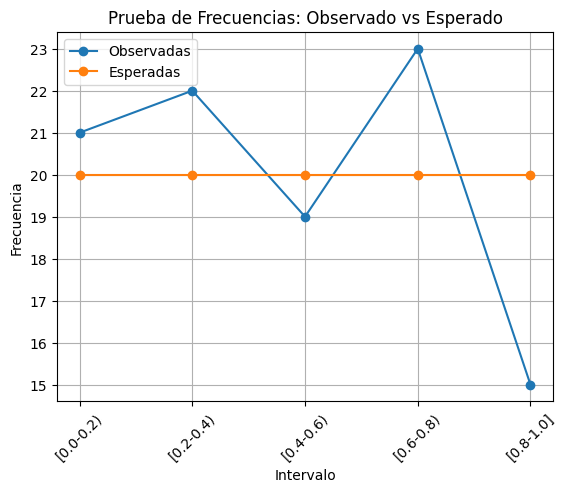

In [9]:
plt.plot(conteos, marker="o", label="Observadas")
plt.plot(esperados, marker="o", label="Esperadas")
plt.title("Prueba de Frecuencias: Observado vs Esperado")
plt.xlabel("Intervalo")
plt.ylabel("Frecuencia")
plt.xticks(range(len(intervalos)), intervalos, rotation=45)
plt.legend()
plt.grid(True)
plt.show()